In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

from sklearn import datasets
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

Carguemos los datos y grafiquemos sus dos primeros componentes principales

([], [])

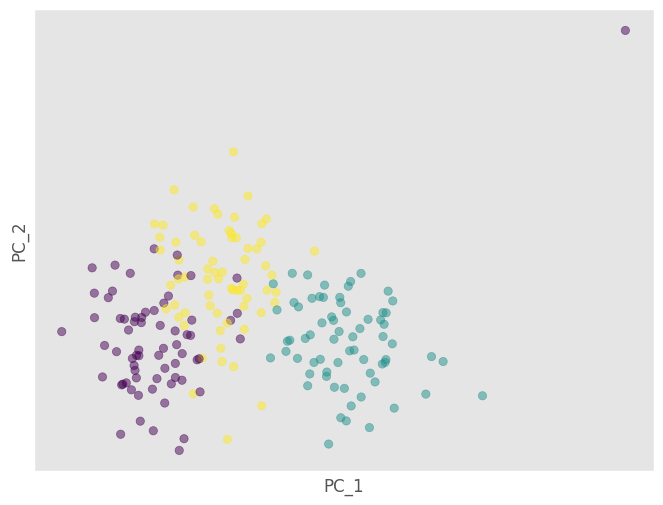

In [ ]:
## Cargo datos de IRIS
#iris = datasets.load_iris()
#X = iris.data
#y = iris.target

# Agrego outliers
#X = np.vstack([np.max(X,axis=0)*2, X])
#y = np.hstack([0, y])

## Cargo datos de WINE
#wine = datasets.load_wine()
#X = wine.data
#y = wine.target

## Genero datos con dimensión n_features (ahora pruebo con 2, pero ver qué pasa cuando lo aumento)
X, y = datasets.make_blobs(n_samples=200, n_features=2, centers=3, center_box=(-10.0, 10.0), cluster_std=3.0, shuffle=True, random_state=13)

# Agrego outliers
X = np.vstack([np.max(X,axis=0)*1.5, X])
y = np.hstack([0, y])


# Proyecto los datos sobre PC_1 y PC_2 para graficar (útil para datos de dimensionalidad mayor a 2)
pca.fit(X)
x_pca = pca.transform(X)

# Grafico los datos con las etiquetas originales
plt.figure(1, figsize=(8, 6))
plt.clf()
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, alpha = 0.5, edgecolor=None)
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.xticks(())
plt.yticks(())

Estas son las etiquetas

In [ ]:
y

array([0, 1, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 1, 1, 2, 1, 1,
       2, 2, 2, 1, 1, 2, 1, 0, 1, 2, 1, 0, 2, 0, 0, 1, 1, 2, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 2, 0, 0, 2, 1, 2, 2, 1, 2,
       0, 1, 1, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 1, 0, 0, 0, 0, 1,
       2, 0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 0, 1, 1, 1, 2, 1, 1, 0, 0, 2,
       0, 2, 0, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 1, 2,
       0, 1, 1, 1, 0, 1, 2, 0, 0, 0, 1, 0, 1, 0, 2, 2, 2, 2, 1, 2, 1, 1,
       1, 0, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 0, 0, 1, 2, 0, 0, 0, 1, 1, 0,
       1, 1, 2])

**OJO**: acá estamos visualizando los primeros 2 componentes, pero las distancias de los puntos a los centroides se calculan sobre el espacio de dimensionalidad original de los datos. Si este espacio original tiene dimensionalidad mayor a 2, cuando visualicemos el etiquetado en el espacio de componentes 2D puede haber etiquetados que parecen "raros" (por ej., un punto cerca de la frontera entre los centroides 1 y 2 se lo etiqueta como "1" cuando está más cerca de "2" en el espacio de dimensionalidad reducida)

# k-means desde cero, sin usar SciKit Learn como para entender qué hace

## Primero, algunas funciones útiles

In [ ]:
# Esta función calcula la distacia euclidea entre dos elementos.

def distancia_euclidea(X1, X2):
    return (sum((X1 - X2)**2))**0.5

In [ ]:
# Asigna los elementos a los clusters de acuerdo a la noción de distancia que
# definimos más arriba
def asignar_clusters(X,centroides):
  etiquetas = []
  for i in range(0,len(X)):
    distancias = []
    for CC in centroides:
      distancias.append(distancia_euclidea(X[i,:], CC) )
    etiquetas.append(np.argmin(distancias) )
  return etiquetas

In [ ]:
# Esta función calcula los centroides

def calcular_centroides(X,etiquetas,k):
  centroides = []
  for j in range(0,k):
    ind = [i for i, e in enumerate(etiquetas) if e==j]
    centroides.append(np.mean(X[ind,:], axis=0))
  return centroides

In [ ]:
# Suma las distancias al centroide dentro de cada cluster (errores cuadráticos),
# y después suma para todos los clusters
def calcula_sse(X,centroides,etiquetas,k):
  se = []
  for j in range(0,k):
    ind = [i for i, e in enumerate(etiquetas) if e==j]
    Y = X[ind,:]
    se.append( sum( [distancia_euclidea(y,centroides[j])**2 for y in Y] ) )

  return sum(se)

In [ ]:
# Elijo el valor de k, en este caso se que el mejor es 3, pero podría probar
# otros.
k = 3

# Corramos k-means a mano

Primero incialicemos los centroides y grafiquemoslo encima de los datos con sus etiquetas reales (el vector *y*)

([], [])

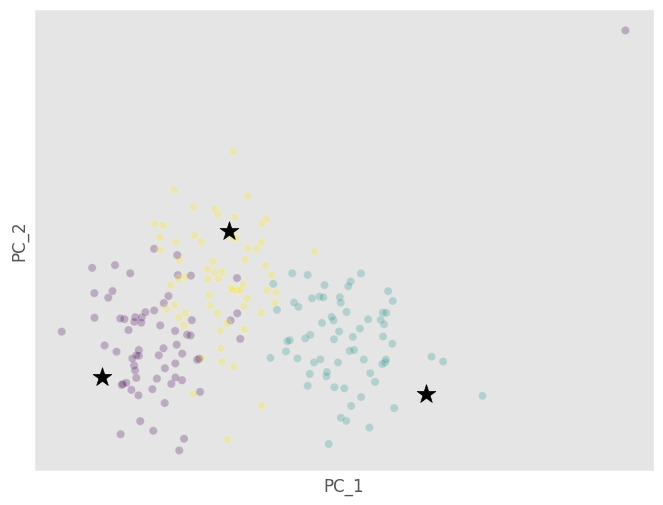

In [ ]:
# Inicialización: Elegir k puntos al azar, por ejemplo entre lo ejemplares del dataset

#Condiciones iniciales aleatoreas
#np.random.seed(0)
idx = np.random.choice(len(X),size=k,replace=False)
centroides = X[idx,:]

#Malas condiciones iniciales: PROBAR QUE PASA SI ELIJO ESTO!
# idx = [0,1,2]
# centroides = X[idx,:]

centroides_pca = pca.transform(centroides) # Llevamos los centroides a las coordenadas de los componentes principales

plt.figure(1, figsize=(8, 6))
plt.clf()

plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, alpha=.25, edgecolor='w')
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], s=200, marker = '*', c='k', edgecolor=None)
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.xticks(())
plt.yticks(())

Calculemos las etiquetas de los puntos con respecto a estos centroides

In [ ]:
etiquetas = asignar_clusters(X,centroides)
np.unique(etiquetas)

array([0, 1, 2])

Grafiquemos la condición inicial con las etiquetas asignadas por los centroides iniciales

([], [])

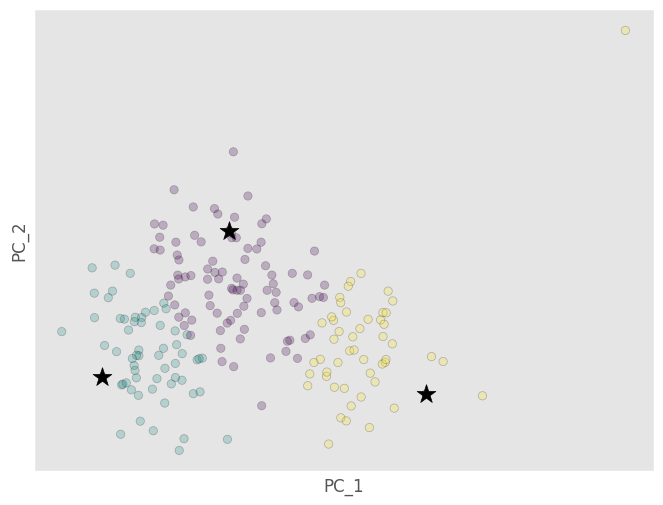

In [ ]:
plt.figure(1, figsize=(8, 6))
plt.clf()
plt.scatter(x_pca[:, 0], x_pca[:, 1],
            c=etiquetas, alpha=.25, edgecolor='k')
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=200, marker = '*', c='k', edgecolor=None)
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.xticks(())
plt.yticks(())

Hagamos la primera iteración: recalculemos centroides

([], [])

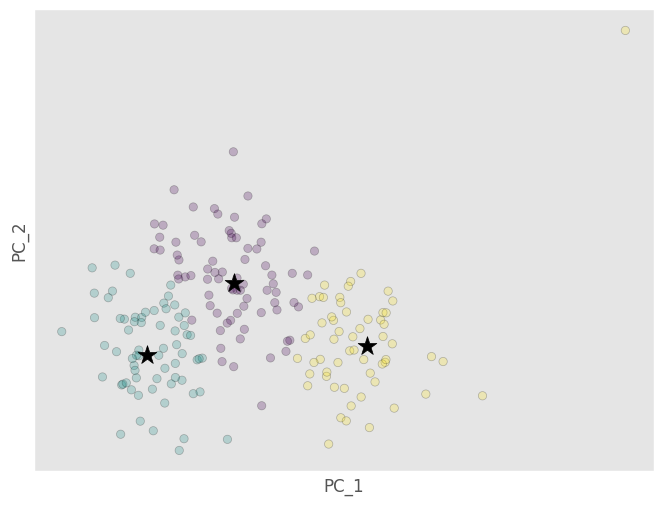

In [ ]:
centroides = calcular_centroides(X,etiquetas,k)
etiquetas = asignar_clusters(X,centroides)

centroides_pca = pca.transform(centroides)

plt.figure(1, figsize=(8, 6))
plt.clf()
plt.scatter(x_pca[:, 0], x_pca[:, 1],
            c=etiquetas, alpha=.25, edgecolor='k')
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=200, marker = '*', c='k', edgecolor=None)
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.xticks(())
plt.yticks(())

Ahora deberíamos recalcular etiquetas y seguir hasta converger....

### Hagamos varias iteraciones y veamos cómo van dando los resultados

-----------------------------------
Cambio de centroides en iteración 0: 51.25605357334763
Cantidad de puntos que cambiaron etiqueta en iteración 0: 14
SSE en iteración 0: 3638.4282880890223
-----------------------------------
Cambio de centroides en iteración 1: 0.5684588081084305
Cantidad de puntos que cambiaron etiqueta en iteración 1: 6
SSE en iteración 1: 3582.3076698946625
-----------------------------------
Cambio de centroides en iteración 2: 0.30832018983797416
Cantidad de puntos que cambiaron etiqueta en iteración 2: 3
SSE en iteración 2: 3548.6748474370474
-----------------------------------
Cambio de centroides en iteración 3: 0.11230172584418852
Cantidad de puntos que cambiaron etiqueta en iteración 3: 3
SSE en iteración 3: 3539.365776669689
-----------------------------------
Cambio de centroides en iteración 4: 0.051076281828961095
Cantidad de puntos que cambiaron etiqueta en iteración 4: 0
SSE en iteración 4: 3535.9704036938497
-----------------------------------
Cambio

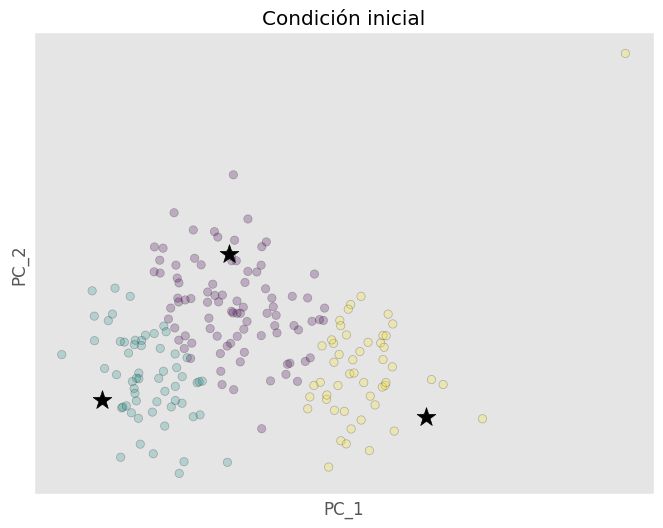

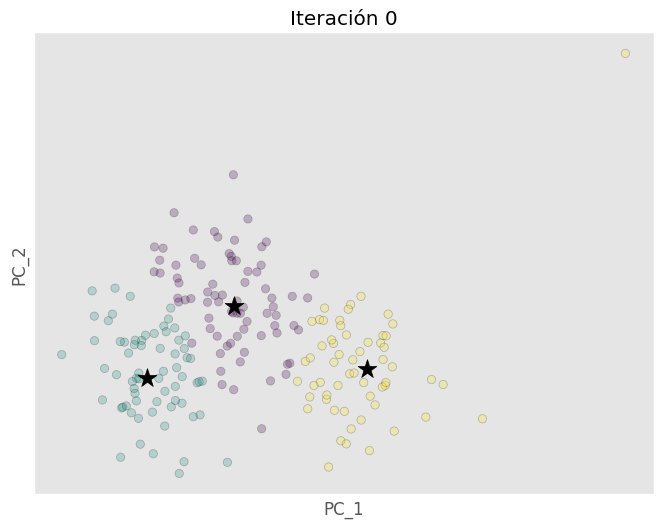

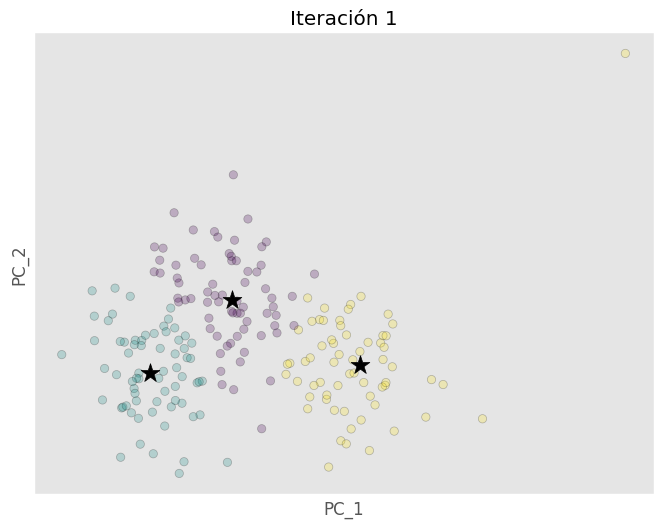

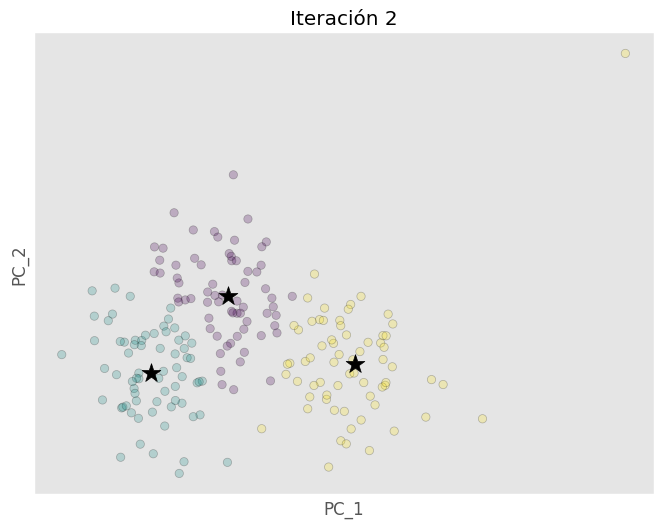

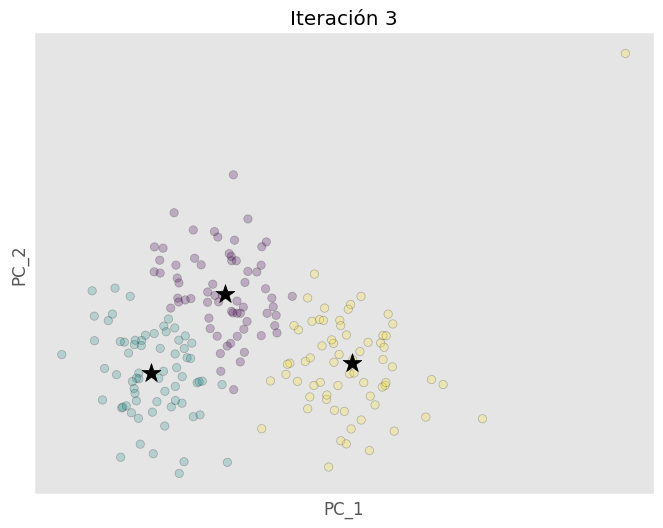

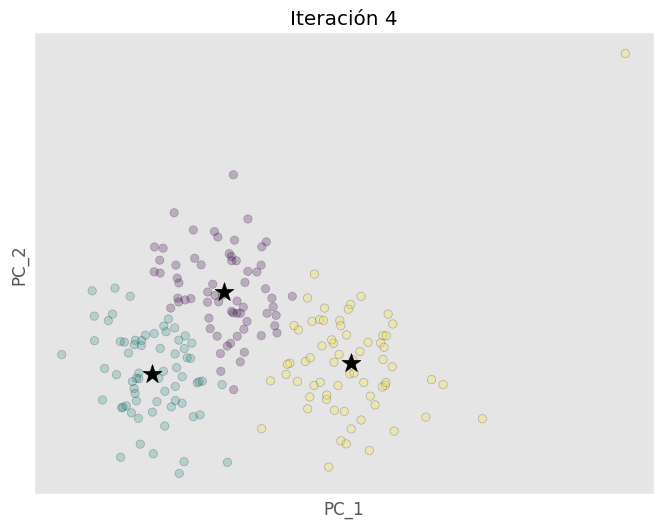

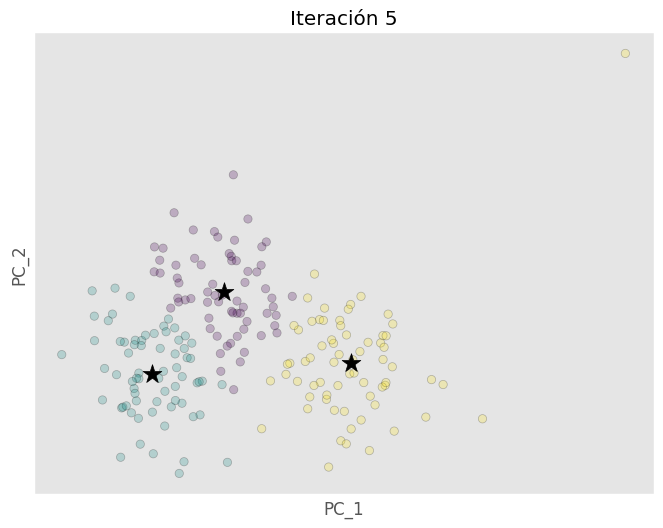

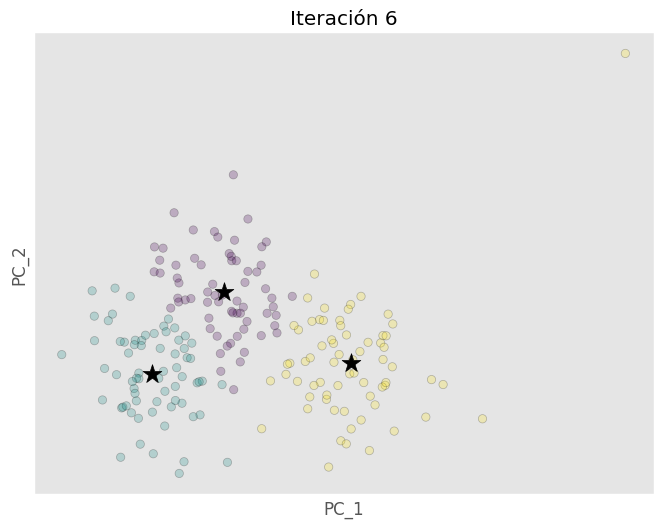

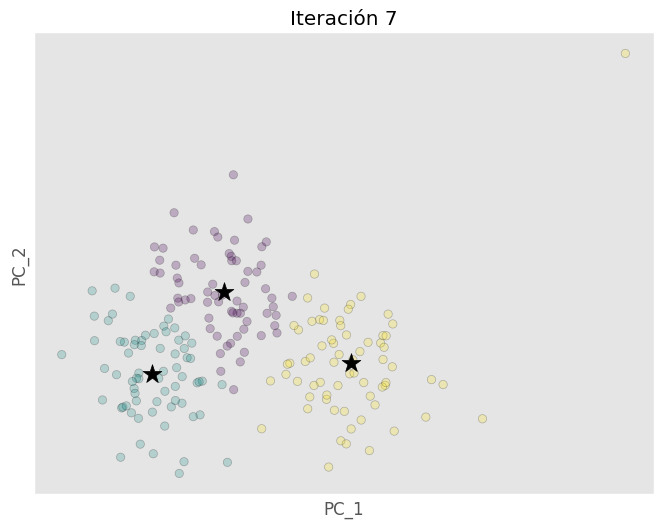

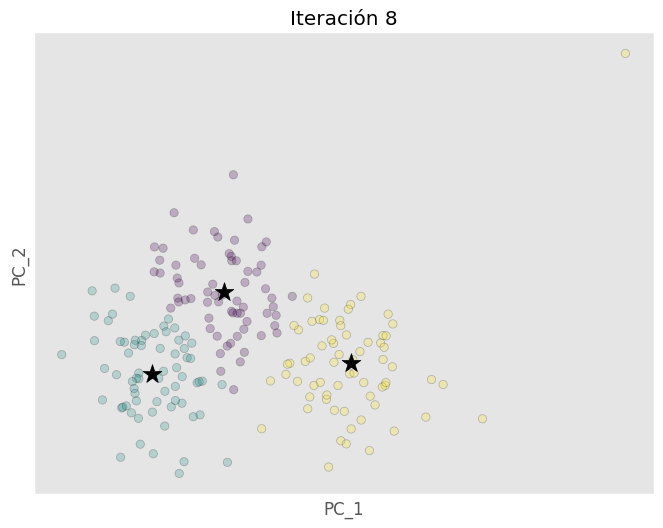

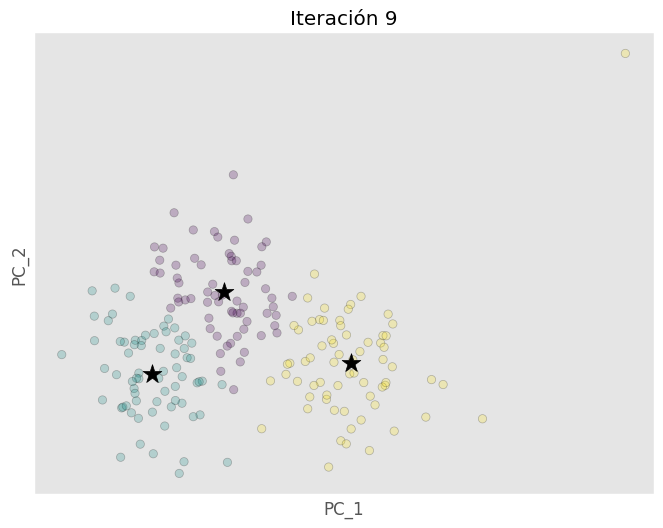

In [ ]:
centroides = X[idx,:]

centroides_pca = pca.transform(centroides)
etiquetas = asignar_clusters(X,centroides)
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1],
            c=etiquetas, alpha=.25, edgecolor='k')
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=200, marker = '*', c='k', edgecolor=None)
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.xticks(())
plt.yticks(())
plt.title('Condición inicial')


n_iter_max = 10
sse = []
for n in range(0,n_iter_max):
  centroides_old = centroides
  etiquetas_old = etiquetas
  centroides = calcular_centroides(X,etiquetas,k)
  etiquetas = asignar_clusters(X,centroides)

  centroides_pca = pca.transform(centroides)
  plt.figure(figsize=(8, 6))
  plt.scatter(x_pca[:, 0], x_pca[:, 1],
            c=etiquetas, alpha=.25, edgecolor='k')
  plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=200, marker = '*', c='k', edgecolor=None)
  plt.title('Iteración ' + str(n))
  plt.xlabel('PC_1')
  plt.ylabel('PC_2')
  plt.xticks(())
  plt.yticks(())

  print('-----------------------------------')
  print('Cambio de centroides en iteración '+ str(n) +':', np.sum(  np.sum( ( np.array(centroides)-np.array(centroides_old) )**2, axis=1 ) ) )
  print('Cantidad de puntos que cambiaron etiqueta en iteración '+ str(n) +':', sum( [new!=old for new, old in zip(etiquetas, etiquetas_old)] ) )
  print('SSE en iteración '+ str(n) + ':', calcula_sse(X,centroides,etiquetas,k) )
  sse.append(calcula_sse(X,centroides,etiquetas,k))
  # Definir algún criterio de parada



Text(0, 0.5, 'SSE')

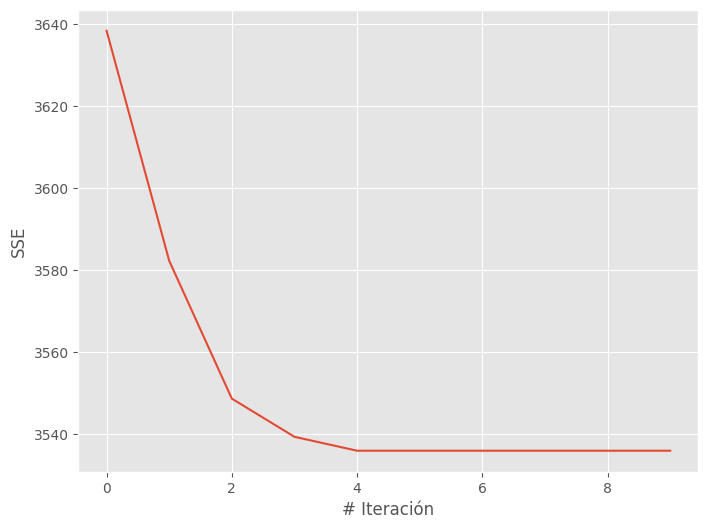

In [ ]:
plt.figure(2, figsize=(8, 6))
plt.clf()
plt.plot(sse)
plt.xlabel('# Iteración')
plt.ylabel('SSE')

# Con SciKitLearn

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=k).fit(X)

([], [])

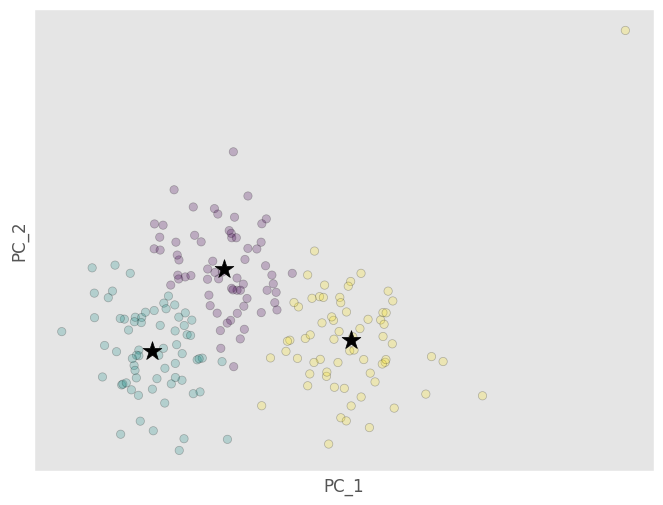

In [ ]:
centroides_sklean_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(1, figsize=(8, 6))
plt.clf()
#plt.scatter(x[:, 0], x[:, 1], color='k', alpha=.25, edgecolor='k')
plt.scatter(x_pca[:, 0], x_pca[:, 1],
            c=kmeans.labels_, alpha=.25, edgecolor='k')
plt.scatter(centroides_sklean_pca[:, 0], centroides_sklean_pca[:, 1],
            s=200, marker = '*', c='k', edgecolor=None)
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.xticks(())
plt.yticks(())